In [ ]:
pip install pyforest

  Preparing metadata (setup.py) ... done
  Created wheel for pyforest: filename=pyforest-1.1.2-py2.py3-none-any.whl size=15902 sha256=e4fa884d8638b9328b3d99b044477894de03dc15e10a928fb5216ce924baf8cf
  Stored in directory: /root/.cache/pip/wheels/66/4f/3c/cbdf5336b5a84f39cb6e3d76eecb9acf3f99a2c072785afecc
Successfully built pyforest


In [ ]:
import pyforest

In [ ]:
df = pd.read_csv(r"/content/hepatitis_csv.csv")
df.head()

<IPython.core.display.Javascript object>

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live


In [ ]:
df.shape

(155, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              155 non-null    int64  
 1   sex              155 non-null    object 
 2   steroid          154 non-null    object 
 3   antivirals       155 non-null    bool   
 4   fatigue          154 non-null    object 
 5   malaise          154 non-null    object 
 6   anorexia         154 non-null    object 
 7   liver_big        145 non-null    object 
 8   liver_firm       144 non-null    object 
 9   spleen_palpable  150 non-null    object 
 10  spiders          150 non-null    object 
 11  ascites          150 non-null    object 
 12  varices          150 non-null    object 
 13  bilirubin        149 non-null    float64
 14  alk_phosphate    126 non-null    float64
 15  sgot             151 non-null    float64
 16  albumin          139 non-null    float64
 17  protime         

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,155.0,41.200000,12.565878,7.0,32.00,39.0,50.00,78.0
bilirubin,149.0,1.427517,1.212149,0.3,0.70,1.0,1.50,8.0
alk_phosphate,126.0,105.325397,51.508109,26.0,74.25,85.0,132.25,295.0
sgot,151.0,85.894040,89.650890,14.0,31.50,58.0,100.50,648.0
albumin,139.0,3.817266,0.651523,2.1,3.40,4.0,4.20,6.4
protime,88.0,61.852273,22.875244,0.0,46.00,61.0,76.25,100.0


In [ ]:
df .isnull().sum()

,0
age,0
sex,0
steroid,1
antivirals,0
fatigue,1
malaise,1
anorexia,1
liver_big,10
liver_firm,11
spleen_palpable,5


In [ ]:
df .fillna('',inplace=True)

/tmp/ipython-input-3147056481.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df .fillna('',inplace=True)


In [ ]:
df .isnull().sum()

,0
age,0
sex,0
steroid,0
antivirals,0
fatigue,0
malaise,0
anorexia,0
liver_big,0
liver_firm,0
spleen_palpable,0


In [ ]:
df['sex']= df['sex'].map({'male': 1,'female':0})

In [ ]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,1,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,85.0,18.0,4.0,NaN,False,1
1,50,0,0.0,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,135.0,42.0,3.5,NaN,False,1
2,78,0,1.0,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.7,96.0,32.0,4.0,NaN,False,1
3,31,0,NaN,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.7,46.0,52.0,4.0,80.0,False,1
4,34,0,1.0,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,200.0,4.0,NaN,False,1


<IPython.core.display.Javascript object>

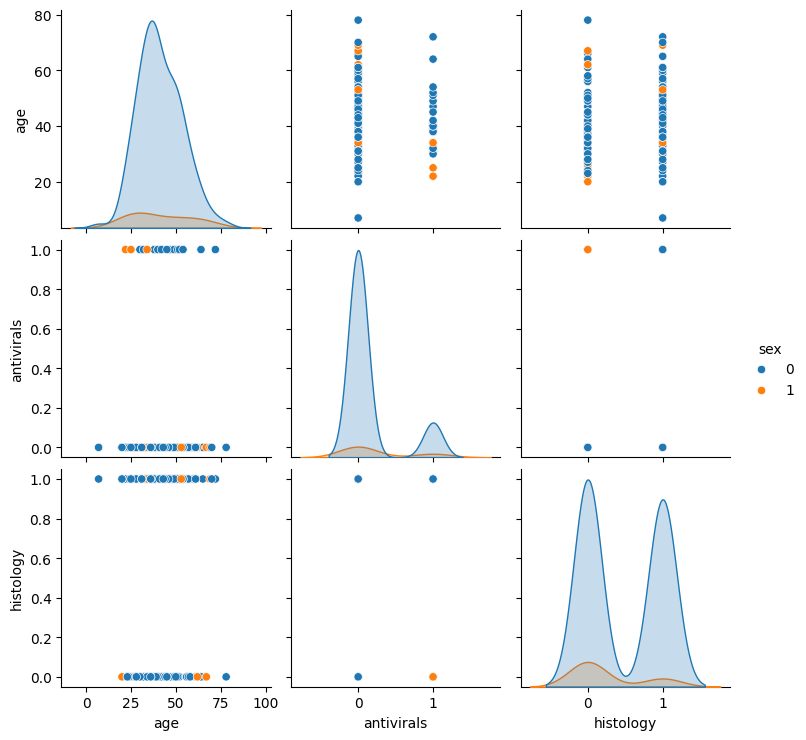

In [ ]:
sns.pairplot(data =df,hue = 'sex')

In [ ]:
df['class'] = df['class'].map({'live':1,'die' :0})

In [ ]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,1,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,,False,1
1,50,0,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,,False,1
2,78,0,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,,False,1
3,31,0,,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,1
4,34,0,True,False,False,False,False,True,False,False,False,False,False,1.0,,200.0,4.0,,False,1


In [ ]:
df =df .apply(pd.to_numeric)

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,1,0.0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,85.0,18.0,4.0,NaN,False,1
1,50,0,0.0,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,135.0,42.0,3.5,NaN,False,1
2,78,0,1.0,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.7,96.0,32.0,4.0,NaN,False,1
3,31,0,NaN,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.7,46.0,52.0,4.0,80.0,False,1
4,34,0,1.0,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,200.0,4.0,NaN,False,1


In [ ]:
df.groupby(['sex','fatigue']).agg({'class':sum})

/tmp/ipython-input-795442287.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df.groupby(['sex','fatigue']).agg({'class':sum})


class
sex fatigue       
0   0.0         48
    1.0         58
1   0.0          4
    1.0         12

<IPython.core.display.Javascript object>

<Axes: xlabel='liver_big', ylabel='count'>

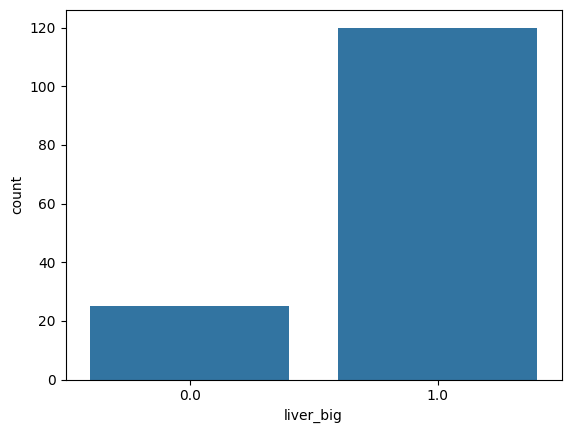

In [ ]:
sns.countplot(x='liver_big',data= df)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

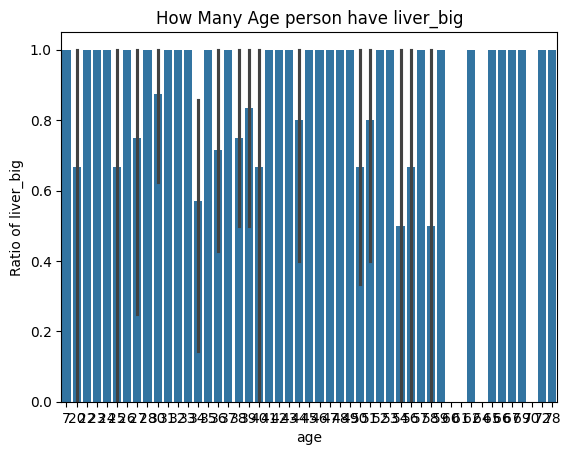

In [ ]:
sns.barplot(x='age',y='liver_big',data=df)
plt.title('How Many Age person have liver_big')
plt.xlabel('age')
plt.ylabel('Ratio of liver_big')
plt.show()

In [ ]:
#Split Dataset
x= df.drop(columns=['class'])
y= df['class']
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
150    0
151    1
152    1
153    1
154    0
Name: class, Length: 155, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#Split data into training and test sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape,y_train.shape

((124, 19), (124,))

In [ ]:
x_test.shape,y_test.shape

((31, 19), (31,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Train a Random Forest Classifier
Rf = RandomForestClassifier(random_state=42)
Rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Make prediction
y_pred = Rf.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
y_proba = Rf.predict_proba(x_test)[:, 1]
y_proba

array([0.95, 0.53, 0.97, 0.99, 0.61, 0.96, 0.87, 0.49, 0.52, 0.94, 0.99,
       0.39, 0.94, 0.97, 0.47, 0.94, 0.79, 0.73, 0.98, 0.6 , 0.96, 1.  ,
       0.99, 0.93, 0.88, 0.56, 0.91, 0.97, 0.76, 0.83, 0.74])

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score, roc_curve

In [ ]:
# Evaluate the model
print("Classification Report:\n", classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.29      0.40         7
           1       0.82      0.96      0.88        24

    accuracy                           0.81        31
   macro avg       0.74      0.62      0.64        31
weighted avg       0.79      0.81      0.78        31



In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

Confusion Matrix:
 [[ 2  5]
 [ 1 23]]


In [ ]:
print("ROC -AUC Score:", roc_auc_score(y_test,y_proba))

ROC -AUC Score: 0.7738095238095238


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

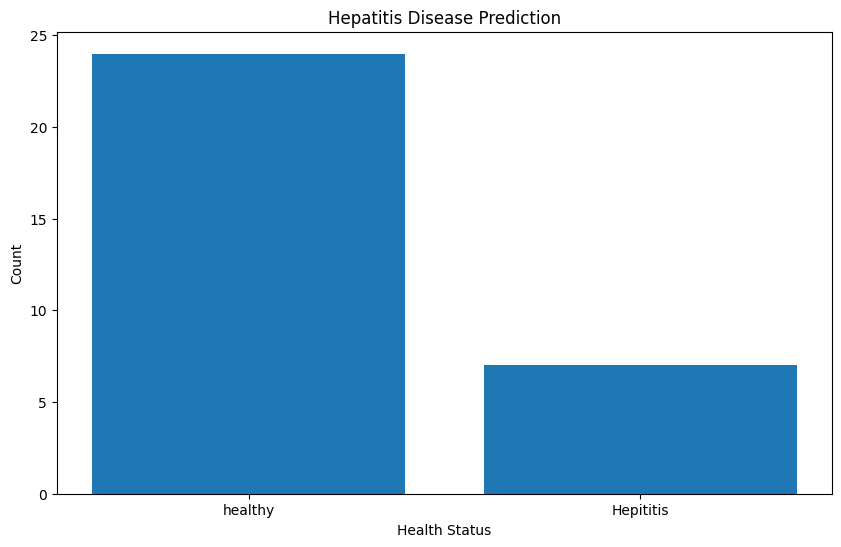

In [ ]:
# Visualize the Results
plt.figure(figsize=(10,6))
plt.bar(['healthy', 'Hepititis'], [y_test.sum(), len(y_test) - y_test.sum()])
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.title('Hepatitis Disease Prediction')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

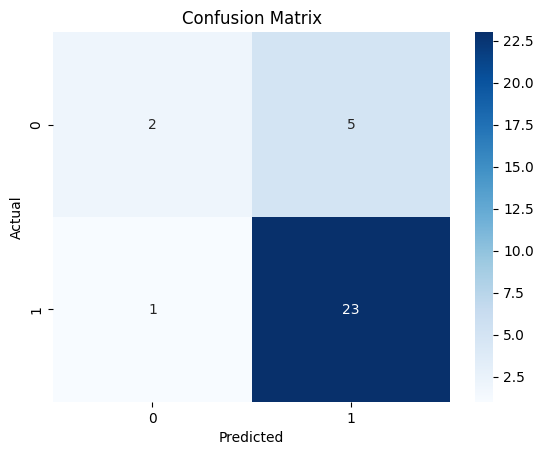

In [ ]:
# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

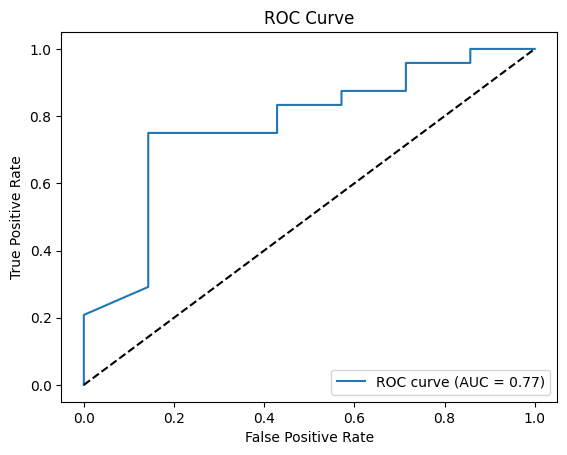

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()